# Meep's broadband bend: reference recreation and fabrication-robust refinement

## Goal

Recreate Meep's **Filtering and Thresholding Design Parameters and Broadband Objective Functions** notebook as a local BeamZ inverse-design experiment. We preserve the reference's physical design problem and MMA continuation schedule, then independently verify the resulting device.

**Saved-run result:** the robust binary design improves worst sampled transmission from **13.44% to 89.33%** across five thresholds and 29 wavelengths on a 25 nm mesh, with **93.27%** nominal mean transmission. The 12.5 nm check gives **13.23% → 92.01%** for the baseline/robust minima over three optimized thresholds and ten training wavelengths. The notebook retains the original Meep recreation, an equal-compute nominal control, and the complete comparison.

Reference: [rendered Meep notebook](https://nbviewer.org/github/NanoComp/meep/blob/cedb7aef80dc2c4ac2c9c981b916a2ce50fcfb01/python/examples/adjoint_optimization/03-Filtered_Waveguide_Bend.ipynb), [pinned source](https://github.com/NanoComp/meep/blob/cedb7aef80dc2c4ac2c9c981b916a2ce50fcfb01/python/examples/adjoint_optimization/03-Filtered_Waveguide_Bend.ipynb), commit `cedb7aef80dc2c4ac2c9c981b916a2ce50fcfb01`. The original is part of the [Meep adjoint tutorials](https://meep.readthedocs.io/en/latest/Python_Tutorials/Adjoint_Solver/).

| Reference choice | This recreation |
|---|---|
| Silicon / silica indices | **3.4 / 1.44**, lossless and nondispersive |
| Input and output | **0.5 µm** wide; left input, upper output |
| Design region / simulation cell | **2.5 × 2.5 µm / 5.5 × 5.0 µm**, with **1 µm PML** |
| Training wavelengths | **10 equally spaced wavelengths from 1.5 to 1.6 µm** |
| Spatial resolution / design nodes | **20 pixels/µm (50 nm) / 51 × 51 nodes** |
| Filter and projection | Conic radius **0.201246 µm**, tanh threshold **0.5** |
| Boundary and symmetry mapping | Same fixed silicon/silica boundary nodes and post-projection anti-diagonal symmetry |
| Objective | Mean of output fundamental-mode power / input forward fundamental-mode power |
| Optimization | **MMA, 12 evaluations at each β = 4, 8, 16, 32, 64, 128** |

**Numerical differences:** BeamZ uses its own Yee discretization, CPML, mode solver, source injection, and checkpointed JAX reverse differentiation. The reference's nodal material is bilinearly sampled onto BeamZ's cell density grid; this is not Meep's exact material interpolation/subpixel treatment. We match the Gaussian envelope width and peak time, but not Meep's discrete dipole-current waveform. A fixed **700 fs** run replaces Meep's decay-based stopping. These are recorded differences, not a claim that the two solvers return identical numbers. Meep itself is not run by this notebook.

**Part I** recreates the nominal Meep optimization. **Part II, in this same notebook**, adds worst-case optimization across dilated, nominal, and eroded threshold scenarios, plus a nominal-only control with the same FDTD gradient budget. The reference's 90 nm length-scale parameter sets the filter radius; neither part enforces a hard minimum feature size. Threshold scenarios perturb only the design region, with fixed straight leads, and are not calibrated etch offsets in nanometres.


## Setup

From the BeamZ repository, install `uv sync --extra dev --extra mma` and select that environment's Python kernel. `nlopt` provides the same MMA algorithm as the reference; JAX runs the electromagnetic solve locally. No Meep installation or cloud account is required.

All cells execute in order. The optimization performs 72 MMA evaluations; compilation and finer-grid verification add runtime. Results are saved under `results/topology_examples/`. Saved notebook figures can be viewed without rerunning.


The robust extension adds two independent refinements, run in two local worker threads. Each uses 216 forward/adjoint gradient evaluations, followed by binary-geometry verification. Allow substantially more time than for the nominal reference alone. Stage-end parameter files are saved, but rerunning the notebook starts fresh for reproducibility.

In [1]:
from pathlib import Path
import importlib.metadata
import platform
import time
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.signal import convolve2d
import nlopt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as PlotRectangle
from IPython.display import display, Markdown
from shapely.geometry import box
from beamz import (LIGHT_SPEED, Design, Material, Rectangle, ModeSource,
                   ModeSpec, ModeMonitor, FieldMonitor, GaussianPulse, PML, Simulation)
from beamz.optimization import TopologySpec, TopologyProblem, ModePower
from beamz.optimization.polygonize import density_to_shapely_geometry, shapely_geometry_to_polygons

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13,
                     "axes.spines.top": False, "axes.spines.right": False})
blue, orange, gray = "#2166ac", "#b35806", "#555555"
repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
artifact_dir = repo / "results" / "topology_examples"
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f"Python {platform.python_version()} | BeamZ {importlib.metadata.version('beamz')} | "
      f"JAX {jax.__version__} ({jax.default_backend()}) | NLopt {nlopt.__version__}")

def show_table(headers, rows):
    display(Markdown(" | ".join(headers) + "\n" + " | ".join(["---"] * len(headers))
                     + "\n" + "\n".join(" | ".join(str(v) for v in row) for row in rows)))


Python 3.11.14 | BeamZ 0.5.1 | JAX 0.9.0 (cpu) | NLopt 2.11.0


## Steps

### 1. Translate the reference simulation

Meep centers the domain at the origin. BeamZ's 2D coordinates start at the lower-left corner, so every point is translated by **(2.75, 2.5) µm**. The reference top-monitor coordinate uses **Sx**, not Sy; that detail is retained. Both guides extend through the PML.

We excite the out-of-plane electric fundamental mode, corresponding to BeamZ's **TM (Ez, Hx, Hy)** convention. Meep names its objective coefficient `TE0`; polarization names depend on convention. Both physical field components and propagation directions matter more than the label.

Meep's Gaussian envelope has time width $1/f_\mathrm{width}$ and peak time $5/f_\mathrm{width}$. BeamZ defines width as $1/(2\pi f_\mathrm{width})$, so the parameters below convert that convention explicitly. Transmission is normalized to the measured incident mode at each wavelength.


In [2]:
um = 1e-6
resolution = 0.05 * um
wavelengths = np.linspace(1.5, 1.6, 10) * um
frequencies = LIGHT_SPEED / wavelengths
core, cladding = Material(permittivity=3.4**2), Material(permittivity=1.44**2)
design = Design(width=5.5 * um, height=5.0 * um, material=cladding)
# The design region overwrites the overlapping portions of Meep's two guides.
# Here only the fixed portions outside that region are drawn.
design += Rectangle(position=(0, 2.25 * um), width=1.5 * um, height=0.5 * um, material=core)
design += Rectangle(position=(2.5 * um, 3.75 * um), width=0.5 * um, height=1.25 * um, material=core)
center_frequency = LIGHT_SPEED / (1.55 * um)
meep_fwidth = 0.1 * center_frequency
source = ModeSource(
    center=(7 / 6 * um, 2.5 * um, 0), size=(0, 5 * um, um), direction="+",
    mode_spec=ModeSpec(num_modes=1, polarization="tm"),
    source_time=GaussianPulse(freq0=center_frequency, fwidth=meep_fwidth / (2 * np.pi),
                              offset=5 / (2 * np.pi)),
)
incoming = ModeMonitor(
    center=(4 / 3 * um, 2.5 * um, 0), size=(0, 5 * um, um), freqs=frequencies,
    mode_spec=ModeSpec(num_modes=1, polarization="tm"), name="input",
)
top = incoming.updated_copy(center=(2.75 * um, 47 / 12 * um, 0), size=(5.5 * um, 0, um), name="top")
simulation = Simulation(
    design=design, resolution=resolution, run_time=700e-15, sources=[source],
    monitors=[incoming, top], polarization="tm",
    boundaries=[PML(thickness=um, formulation="cpml")],
)
grid = simulation.compile(backend="jax").grid
mask = np.zeros(grid.material_grid.shape, dtype=bool)
mask[25:75, 30:80] = True  # x = 1.5..4.0 µm; y = 1.25..3.75 µm
topology = TopologySpec(
    design=design, region_mask=mask, resolution=resolution,
    eps_min=1.44**2, eps_max=3.4**2, filter_radius=0, projection_type="identity",
)
problem = TopologyProblem(simulation, topology, ModePower("top", reference_monitor="input"))
print(f"Cell grid: {mask.shape}; design nodes: 51 × 51; timesteps: {len(simulation.time)}")
print(f"Gaussian envelope width: {1 / meep_fwidth * 1e15:.2f} fs; peak: {5 / meep_fwidth * 1e15:.2f} fs")


Cell grid: (100, 110); design nodes: 51 × 51; timesteps: 5997
Gaussian envelope width: 51.70 fs; peak: 258.51 fs


### 2. Recreate the nodal mapping

The reference uses endpoint-inclusive 51×51 design nodes. Its sequence is: **fix boundary nodes → conic filter → tanh projection → symmetry average**. The symmetry operation is reflection across the anti-diagonal, exchanging the input and output arms. Meep's prose calls it “90-degree symmetry”; the operation here matches its code.

The filter radius is $0.09/[2\sqrt{0.55-0.5}]$ µm. We retain its fractional number of grid cells, edge padding, and normalized conic weights. This JAX mapping was checked against the pinned Meep filter functions during development: maximum absolute discrepancies on a seeded random array were below $1.3\times10^{-5}$ through β = 2048.

`projection_type="identity"` makes BeamZ accept this already-mapped density. JAX's vector–Jacobian product then carries the electromagnetic gradient back to the 51×51 nodal parameters, including the fixed boundaries and symmetry operation.


In [3]:
node_coordinates = np.linspace(-1.25, 1.25, 51)
node_x, node_y = np.meshgrid(node_coordinates, node_coordinates, indexing="xy")
silicon_nodes = (((node_x == -1.25) & (abs(node_y) <= 0.25))
                 | ((node_y == 1.25) & (abs(node_x) <= 0.25)))
boundary_nodes = (abs(node_x) == 1.25) | (abs(node_y) == 1.25)
silica_nodes = boundary_nodes & ~silicon_nodes
filter_radius_um = 0.09 / (2 * np.sqrt(0.55 - 0.5))
kernel_half_width = int(np.ceil(filter_radius_um / 0.05))
kernel_y, kernel_x = np.mgrid[-kernel_half_width:kernel_half_width + 1,
                              -kernel_half_width:kernel_half_width + 1] * 0.05
kernel = np.maximum(0, 1 - np.hypot(kernel_x, kernel_y) / filter_radius_um)
kernel = jnp.asarray(kernel / kernel.sum())

@jax.jit
def mapped_nodes(parameters, beta, eta=0.5):
    values = jnp.reshape(parameters, (51, 51))
    values = jnp.where(silicon_nodes, 1.0, jnp.where(silica_nodes, 0.0, values))
    filtered = convolve2d(jnp.pad(values, kernel_half_width, mode="edge"), kernel, mode="valid")
    projected = ((jnp.tanh(beta * eta) + jnp.tanh(beta * (filtered - eta)))
                 / (jnp.tanh(beta * eta) + jnp.tanh(beta * (1 - eta))))
    return 0.5 * (projected + jnp.rot90(projected.T, 2))

@jax.jit
def material_density(parameters, beta, eta=0.5):
    nodes = mapped_nodes(parameters, beta, eta)
    # Bilinear interpolation at the centers of the 50 × 50 design cells.
    cells = 0.25 * (nodes[:-1, :-1] + nodes[1:, :-1] + nodes[:-1, 1:] + nodes[1:, 1:])
    return jnp.zeros(mask.shape).at[25:75, 30:80].set(cells)

def evaluate(parameters, beta, need_gradient=True):
    density, pullback = jax.vjp(lambda v: material_density(v, beta),
                              jnp.asarray(parameters, dtype=jnp.float32))
    if not need_gradient:
        return problem.value(density)
    value, physical_gradient = problem.value_and_grad(density)
    return value, np.asarray(pullback(jnp.asarray(physical_gradient))[0], dtype=float)

initial_parameters = np.full(51 * 51, 0.5)
initial_parameters[silicon_nodes.ravel()] = 1
initial_parameters[silica_nodes.ravel()] = 0
print(f"Conic radius: {filter_radius_um:.9f} µm; free nodal parameters: {(~boundary_nodes).sum()}")


Conic radius: 0.201246118 µm; free nodal parameters: 2401


### 3. Show the reference's dilation/intermediate/erosion demonstration

Use a deterministic random array for this visualization, separate from the uniform 0.5 optimization seed. The three thresholds **0.498 / 0.5 / 0.502** and β = **2048** match the reference demonstration. A lower threshold adds silicon; a higher threshold removes it. A threshold shift is not a calibrated etch offset in nanometres.


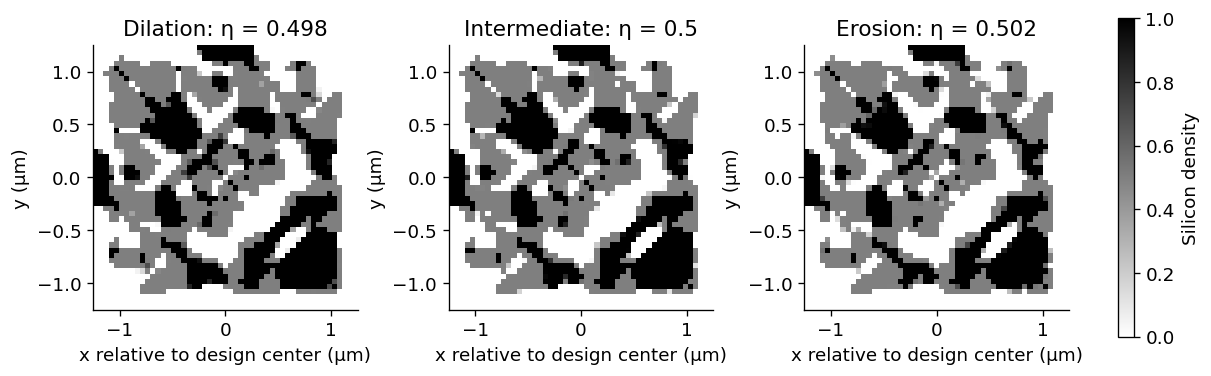

In [4]:
demo_parameters = np.random.default_rng(42).uniform(size=51 * 51)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), layout="constrained")
for ax, eta, label in zip(axes, [0.498, 0.5, 0.502], ["Dilation", "Intermediate", "Erosion"]):
    density = np.asarray(mapped_nodes(demo_parameters, 2048, eta))
    image = ax.imshow(density, origin="lower", extent=(-1.25, 1.25, -1.25, 1.25),
                      cmap="gray_r", vmin=0, vmax=1)
    ax.set(title=f"{label}: η = {eta}", xlabel="x relative to design center (µm)", ylabel="y (µm)")
fig.colorbar(image, ax=axes, label="Silicon density", shrink=0.8)
plt.show()


### 4. Check the complete composed gradient

This directional finite difference checks the full chain: node constraints, filtering, projection, symmetry, interpolation, FDTD, modal decomposition, and normalization across ten wavelengths. Zero directions on the fixed boundary keep all perturbed parameters feasible. This checks the derivative of BeamZ's discretized problem; it does not establish equivalence to Meep's solver.


The first two step sizes agree within 1% in this saved run. At h = 0.003, subtraction of float32 objective values increases relative error to 3.74%; the absolute derivative error remains below the 3×10⁻⁶ gate. The table retains that cancellation-sensitive check rather than hiding it.

In [5]:
initial_value, gradient = evaluate(initial_parameters, beta=4)
direction = np.random.default_rng(7).normal(size=initial_parameters.shape)
direction[boundary_nodes.ravel()] = 0
direction /= np.linalg.norm(direction)
adjoint_derivative = float(np.dot(gradient, direction))
gradient_rows = []
for h in [0.03, 0.01, 0.003]:
    finite_difference = (evaluate(initial_parameters + h * direction, 4, False)
                         - evaluate(initial_parameters - h * direction, 4, False)) / (2 * h)
    relative_error = abs(finite_difference - adjoint_derivative) / max(abs(adjoint_derivative), 1e-12)
    gradient_rows.append([h, f"{adjoint_derivative:.8g}", f"{finite_difference:.8g}", f"{100 * relative_error:.3f}"])
    assert np.isclose(finite_difference, adjoint_derivative, rtol=0.01, atol=3e-6)
assert np.all(gradient[boundary_nodes.ravel()] == 0)
mapped = np.asarray(mapped_nodes(initial_parameters, 4))
np.testing.assert_allclose(mapped, np.rot90(mapped.T, 2), atol=1e-7)
show_table(["h", "Adjoint derivative", "Finite difference", "Relative error (%)"], gradient_rows)


h | Adjoint derivative | Finite difference | Relative error (%)
--- | --- | --- | ---
0.03 | -5.8353648e-05 | -5.8362881e-05 | 0.016
0.01 | -5.8353648e-05 | -5.8859587e-05 | 0.867
0.003 | -5.8353648e-05 | -6.0535967e-05 | 3.740

### 5. Run the same MMA continuation schedule

Restart MMA at each β, as in the reference, with 12 objective evaluations per stage. Fixed boundary nodes use identical lower/upper bounds. The recorded evaluation history includes trial points rejected by MMA, so it need not increase monotonically. The final accepted point can differ from the last trial evaluation.

The objective is the average normalized transmission. Reflection is measured afterward; adding it as a penalty here would change the reference problem.


In [6]:
parameters = initial_parameters.copy()
lower_bounds, upper_bounds = np.zeros_like(parameters), np.ones_like(parameters)
lower_bounds[silicon_nodes.ravel()] = 1
upper_bounds[silica_nodes.ravel()] = 0
betas = [4, 8, 16, 32, 64, 128]
evaluation_history, stage_history, stage_parameters = [], [], []
start = time.perf_counter()
for beta in betas:
    def mma_objective(values, gradient_buffer):
        value, gradient = evaluate(values, beta)
        if gradient_buffer.size:
            gradient_buffer[:] = gradient
        evaluation_history.append((beta, value))
        return value

    optimizer = nlopt.opt(nlopt.LD_MMA, parameters.size)
    optimizer.set_lower_bounds(lower_bounds)
    optimizer.set_upper_bounds(upper_bounds)
    optimizer.set_max_objective(mma_objective)
    optimizer.set_maxeval(12)
    parameters = optimizer.optimize(parameters)
    accepted_value = evaluate(parameters, beta, False)
    stage_history.append((beta, accepted_value))
    stage_parameters.append(parameters.copy())
    print(f"β = {beta:3d}: accepted mean transmission = {100 * accepted_value:.3f}%")
elapsed = time.perf_counter() - start
final_beta = betas[-1]  # 128: the reference also verifies at its last optimized beta.
final_value = stage_history[-1][1]
assert len(evaluation_history) == 72
assert final_value > initial_value + 0.5
np.savez_compressed(artifact_dir / "meep_filtered_bend.npz", parameters=parameters,
                    stage_parameters=np.asarray(stage_parameters), evaluation_history=evaluation_history,
                    stage_history=stage_history, wavelengths=wavelengths,
                    reference_commit="cedb7aef80dc2c4ac2c9c981b916a2ce50fcfb01", final_beta=final_beta)
print(f"{len(evaluation_history)} MMA evaluations in {elapsed:.1f} s; "
      f"initial mean = {100 * initial_value:.3f}%; final accepted mean = {100 * final_value:.3f}%")


β =   4: accepted mean transmission = 74.318%


β =   8: accepted mean transmission = 89.136%


β =  16: accepted mean transmission = 99.295%


β =  32: accepted mean transmission = 98.205%


β =  64: accepted mean transmission = 98.106%


β = 128: accepted mean transmission = 98.499%
72 MMA evaluations in 201.7 s; initial mean = 1.040%; final accepted mean = 98.499%


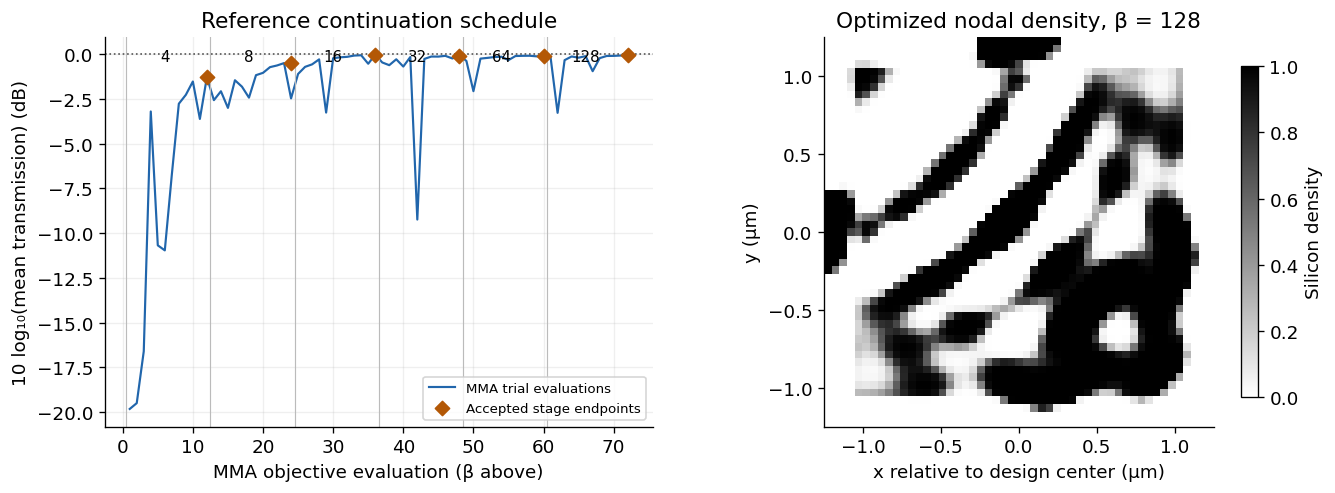

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
scores = np.asarray(evaluation_history)[:, 1]
axes[0].plot(np.arange(1, 73), 10 * np.log10(scores), color=blue, linewidth=1.3, label="MMA trial evaluations")
axes[0].scatter(np.arange(12, 73, 12), 10 * np.log10(np.asarray(stage_history)[:, 1]),
                color=orange, marker="D", label="Accepted stage endpoints", zorder=3)
for stage, beta in enumerate(betas):
    axes[0].axvline(12 * stage + 0.5, color="#bbbbbb", linewidth=0.7)
    axes[0].text(12 * stage + 6, 0.97, str(beta), transform=axes[0].get_xaxis_transform(),
                 ha="center", va="top", fontsize=9)
axes[0].axhline(0, color=gray, linestyle=":", linewidth=1)
axes[0].set(xlabel="MMA objective evaluation (β above)", ylabel="10 log₁₀(mean transmission) (dB)",
            title="Reference continuation schedule")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.2)
nodes = np.asarray(mapped_nodes(parameters, final_beta))
image = axes[1].imshow(nodes, origin="lower", extent=(-1.25, 1.25, -1.25, 1.25),
                       cmap="gray_r", vmin=0, vmax=1)
axes[1].set(xlabel="x relative to design center (µm)", ylabel="y (µm)", title="Optimized nodal density, β = 128")
fig.colorbar(image, ax=axes[1], label="Silicon density", shrink=0.85)
plt.show()


## Checks

### 6. Re-solve the continuous material and export a binary device

First compare `TopologyProblem.spectra` with an ordinary BeamZ simulation of the identical continuous material. Then contour the **same 51×51 nodal field** at density 0.5, clip it to the design region, and join it to the fixed guides. That binary geometry is an additional verification artifact; the reference reports its projected material rather than requiring this export.

Any coarse-grid transmission above 100% is shown without clipping. It indicates discretization or modal-measurement error, not optical gain. The binary-device results below come from fresh geometry rasterization.


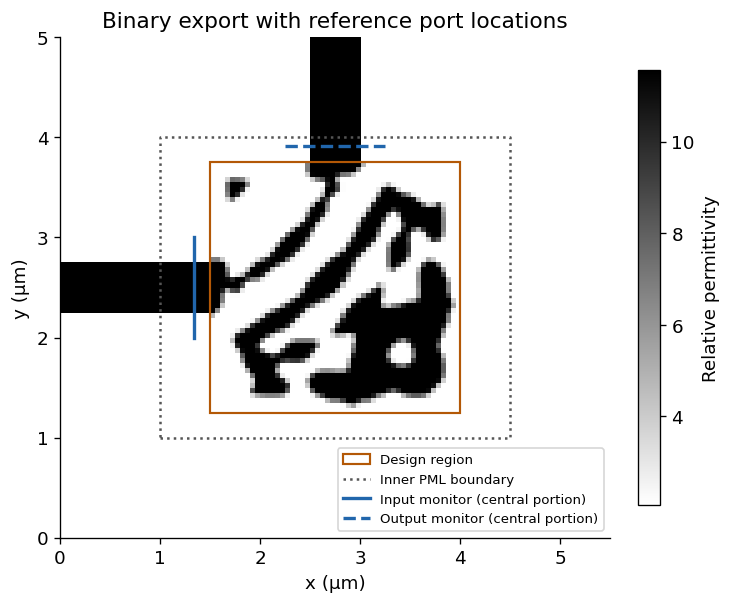

In [8]:
def measured_powers(data):
    incident = abs(data.mode("input").amps.sel(direction="+", mode_index=0).values) ** 2
    transmission = abs(data.mode("top").amps.sel(direction="+", mode_index=0).values) ** 2 / incident
    reflection = abs(data.mode("input").amps.sel(direction="-", mode_index=0).values) ** 2 / incident
    return transmission, reflection

final_density = material_density(parameters, final_beta)
continuous_data = problem.material_simulation(final_density).run(backend="jax", performance=False)
continuous_transmission, continuous_reflection = measured_powers(continuous_data)
np.testing.assert_allclose(problem.spectra(final_density)[0], continuous_transmission, rtol=5e-5, atol=1e-7)

def exported_geometry(values, beta=128, eta=0.5):
    # density_to_shapely_geometry treats samples as cell centers; offset its origin
    # by half a node spacing so contours use the reference's nodal coordinates.
    geometry = density_to_shapely_geometry(np.asarray(mapped_nodes(values, beta, eta)),
        level=0.5, x0=(1.5 - 0.025) * um, y0=(1.25 - 0.025) * um, dx=0.05 * um)
    geometry = geometry.intersection(box(1.5 * um, 1.25 * um, 4.0 * um, 3.75 * um))
    result = design
    for polygon in shapely_geometry_to_polygons(geometry, material=core):
        result += polygon
    return result

binary_design = exported_geometry(parameters)
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
eps = binary_design.rasterize(resolution).permittivity
image = ax.imshow(eps, origin="lower", extent=(0, 5.5, 0, 5), cmap="gray_r",
                   vmin=1.44**2, vmax=3.4**2)
ax.add_patch(PlotRectangle((1.5, 1.25), 2.5, 2.5, fill=False, edgecolor=orange, linewidth=1.3, label="Design region"))
ax.plot([1, 4.5, 4.5, 1, 1], [1, 1, 4, 4, 1], linestyle=":", color=gray, label="Inner PML boundary")
ax.plot([4 / 3, 4 / 3], [2, 3], color=blue, linewidth=2, label="Input monitor (central portion)")
ax.plot([2.25, 3.25], [47 / 12, 47 / 12], color=blue, linestyle="--", linewidth=2, label="Output monitor (central portion)")
ax.set(xlabel="x (µm)", ylabel="y (µm)", title="Binary export with reference port locations")
ax.legend(loc="lower right", fontsize=8)
fig.colorbar(image, ax=ax, label="Relative permittivity", shrink=0.8)
plt.show()


### 7. Check the binary spectrum, mesh, and simulation duration

All verification simulations keep the reference geometry, source, and port coordinates. Only the FDTD mesh and duration change. The 25 nm / 900 fs spectrum additionally uses **21 wavelengths**, including points not used in optimization. We report transmission and reflection separately; unaccounted power can enter radiation or other modes, and finite-grid modal errors also affect the balance.


Verified 50 nm / 700 fs


Verified 25 nm / 700 fs


Verified 25 nm / 900 fs


Verified 12.5 nm / 900 fs


Grid (nm) | Run (fs) | Mean T (%) | Minimum T (%) | Maximum R (%)
--- | --- | --- | --- | ---
50 | 700 | 91.729 | 77.463 | 3.982
25 | 700 | 89.352 | 80.891 | 2.986
25 | 900 | 89.352 | 80.886 | 2.985
12.5 | 900 | 89.771 | 84.235 | 2.907

Largest 700 → 900 fs change: 0.0052 percentage points
Largest 25 → 12.5 nm change: 3.3488 percentage points


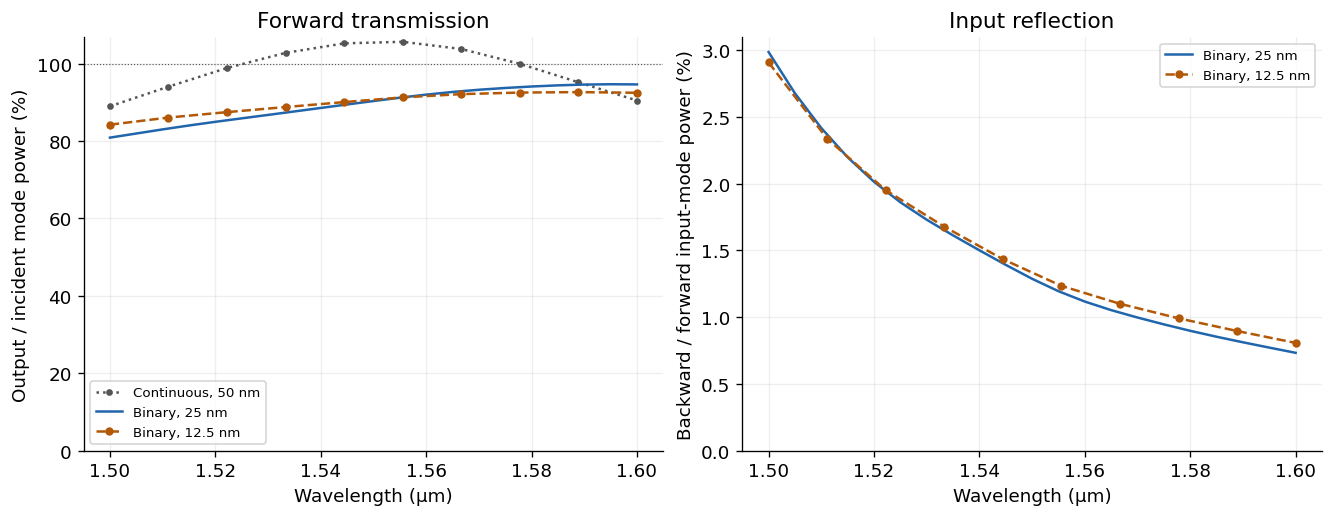

In [9]:
verification = []
for spacing, duration in [(50e-9, 700e-15), (25e-9, 700e-15), (25e-9, 900e-15), (12.5e-9, 900e-15)]:
    data = simulation.updated_copy(design=binary_design, resolution=spacing, run_time=duration).run(
        backend="jax", performance=False)
    transmission, reflection = measured_powers(data)
    verification.append((spacing, duration, transmission, reflection))
    print(f"Verified {spacing * 1e9:g} nm / {duration * 1e15:g} fs")
show_table(["Grid (nm)", "Run (fs)", "Mean T (%)", "Minimum T (%)", "Maximum R (%)"],
           [[f"{dx * 1e9:g}", f"{duration * 1e15:g}", f"{100 * t.mean():.3f}",
             f"{100 * t.min():.3f}", f"{100 * r.max():.3f}"] for dx, duration, t, r in verification])
assert all(np.isfinite(t).all() and np.isfinite(r).all() for _, _, t, r in verification)
runtime_change = np.max(abs(verification[1][2] - verification[2][2]))
mesh_change = np.max(abs(verification[2][2] - verification[3][2]))
print(f"Largest 700 → 900 fs change: {100 * runtime_change:.4f} percentage points")
print(f"Largest 25 → 12.5 nm change: {100 * mesh_change:.4f} percentage points")

sweep_wavelengths = np.linspace(1.5, 1.6, 21) * um
sweep_monitors = [m.updated_copy(freqs=LIGHT_SPEED / sweep_wavelengths) for m in simulation.monitors]
sweep_data = simulation.updated_copy(design=binary_design, resolution=25e-9, run_time=900e-15,
                                     monitors=sweep_monitors).run(backend="jax", performance=False)
sweep_transmission, sweep_reflection = measured_powers(sweep_data)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
axes[0].plot(wavelengths / um, 100 * continuous_transmission, color=gray, linestyle=":", marker=".",
             label="Continuous, 50 nm")
axes[0].plot(sweep_wavelengths / um, 100 * sweep_transmission, color=blue, label="Binary, 25 nm")
axes[0].plot(wavelengths / um, 100 * verification[-1][2], color=orange, linestyle="--", marker="o",
             markersize=4, label="Binary, 12.5 nm")
axes[0].axhline(100, color=gray, linestyle=":", linewidth=0.7)
axes[0].set(title="Forward transmission", ylabel="Output / incident mode power (%)")
axes[1].plot(sweep_wavelengths / um, 100 * sweep_reflection, color=blue, label="Binary, 25 nm")
axes[1].plot(wavelengths / um, 100 * verification[-1][3], color=orange, linestyle="--", marker="o",
             markersize=4, label="Binary, 12.5 nm")
axes[1].set(title="Input reflection", ylabel="Backward / forward input-mode power (%)")
for ax in axes:
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
plt.show()
np.savez_compressed(artifact_dir / "meep_filtered_bend_verification.npz",
    wavelengths=wavelengths, transmission=np.array([v[2] for v in verification]),
    reflection=np.array([v[3] for v in verification]),
    resolutions=np.array([v[0] for v in verification]), durations=np.array([v[1] for v in verification]),
    sweep_wavelengths=sweep_wavelengths, sweep_transmission=sweep_transmission, sweep_reflection=sweep_reflection)


### 8. Assess threshold sensitivity without changing the reference objective

As an extra diagnostic, export designs using **η = 0.45, 0.50, 0.55** and re-simulate at 25 nm. These use the dilation/intermediate/erosion thresholds defined in the reference. They are density-threshold scenarios, not ±nanometre manufacturing errors. The nominal baseline above has not optimized a fabrication-corner objective. The next section uses these same three scenarios during optimization.


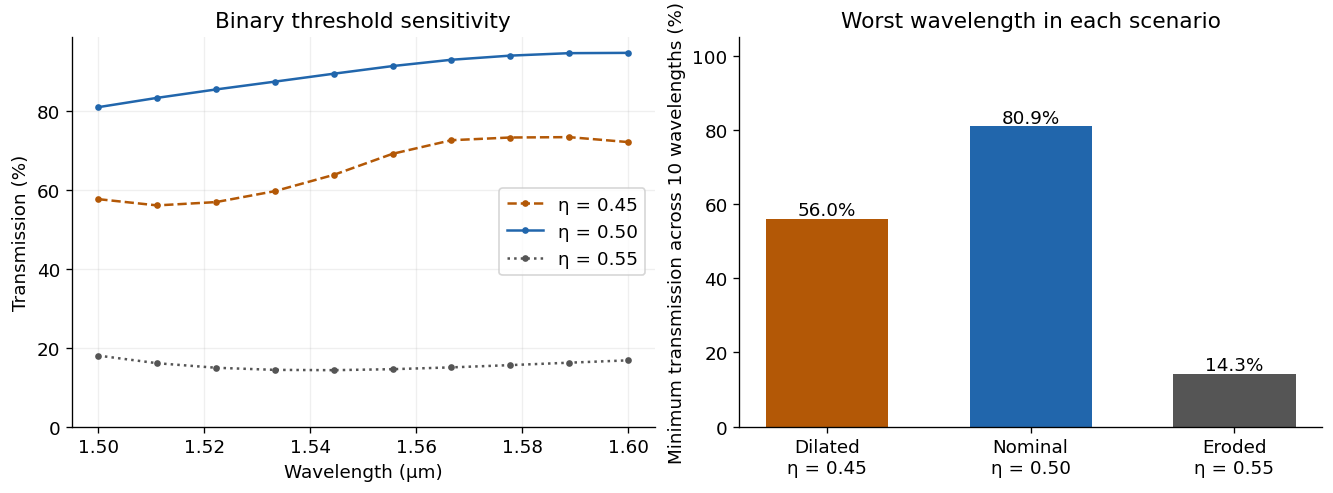

In [10]:
corner_spectra = []
for eta in [0.45, 0.50, 0.55]:
    if eta == 0.50:
        transmission, reflection = verification[2][2:]
    else:
        corner_design = exported_geometry(parameters, eta=eta)
        corner_data = simulation.updated_copy(design=corner_design, resolution=25e-9, run_time=900e-15).run(
            backend="jax", performance=False)
        transmission, reflection = measured_powers(corner_data)
    corner_spectra.append((eta, transmission, reflection))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for (eta, transmission, _), color, style in zip(corner_spectra, [orange, blue, gray], ["--", "-", ":"]):
    axes[0].plot(wavelengths / um, 100 * transmission, color=color, linestyle=style, marker=".", label=f"η = {eta:.2f}")
axes[0].set(xlabel="Wavelength (µm)", ylabel="Transmission (%)", title="Binary threshold sensitivity", ylim=(0, None))
axes[0].legend(); axes[0].grid(alpha=0.2)
etas = np.array([item[0] for item in corner_spectra])
worst = np.array([100 * item[1].min() for item in corner_spectra])
axes[1].bar(["Dilated\nη = 0.45", "Nominal\nη = 0.50", "Eroded\nη = 0.55"], worst,
             color=[orange, blue, gray], width=0.6)
for i, value in enumerate(worst):
    axes[1].text(i, value + 1, f"{value:.1f}%", ha="center")
axes[1].set(ylabel="Minimum transmission across 10 wavelengths (%)",
            title="Worst wavelength in each scenario", ylim=(0, max(105, worst.max() + 8)))
plt.show()


### Nominal baseline summary

This summarizes Part I from its computed arrays. A quantitative cross-solver benchmark still requires running the same final nodal material in Meep with aligned mode conventions and converged material discretizations. Part II below changes the objective explicitly, while keeping the geometry, materials, source, and design parameterization.


In [11]:
finest_t = verification[-1][2]
finest_r = verification[-1][3]
display(Markdown(
    f"**Measured result:** the accepted continuous objective rose from **{100 * initial_value:.2f}%** "
    f"to **{100 * final_value:.2f}%** after 72 MMA evaluations. The binary geometry, verified at "
    f"**12.5 nm / 900 fs**, transmits **{100 * finest_t.min():.2f}–{100 * finest_t.max():.2f}%** "
    f"across the ten training wavelengths (mean **{100 * finest_t.mean():.2f}%**); "
    f"maximum fundamental-mode reflection is **{100 * finest_r.max():.2f}%**. "
    f"The largest 25 → 12.5 nm transmission change is **{100 * mesh_change:.2f} percentage points**. "
    f"Threshold-scenario worst-wavelength transmissions are **{worst[0]:.1f}% / {worst[1]:.1f}% / {worst[2]:.1f}%** "
    "for dilated / nominal / eroded designs. These are simulated 2D results, not fabrication-yield estimates."
))
print("Saved artifacts:", artifact_dir / "meep_filtered_bend.npz",
      artifact_dir / "meep_filtered_bend_verification.npz", sep="\n")


**Measured result:** the accepted continuous objective rose from **1.04%** to **98.50%** after 72 MMA evaluations. The binary geometry, verified at **12.5 nm / 900 fs**, transmits **84.23–92.65%** across the ten training wavelengths (mean **89.77%**); maximum fundamental-mode reflection is **2.91%**. The largest 25 → 12.5 nm transmission change is **3.35 percentage points**. Threshold-scenario worst-wavelength transmissions are **56.0% / 80.9% / 14.3%** for dilated / nominal / eroded designs. These are simulated 2D results, not fabrication-yield estimates.

Saved artifacts:
/Users/quentinwach/.t3/worktrees/beamz-1/t3code-171ec700/results/topology_examples/meep_filtered_bend.npz
/Users/quentinwach/.t3/worktrees/beamz-1/t3code-171ec700/results/topology_examples/meep_filtered_bend_verification.npz


## Part II — Optimize fabrication robustness

### 9. Target the weakest fabrication scenario and wavelength

The nominal design is sensitive to the threshold shifts above. Starting from its final parameters, we now maximize a smooth lower bound on the weakest transmission among **30 scenario/wavelength pairs**:

$$J_\mathrm{robust}(u)=-\tau\log\sum_{\eta\in\{0.45,0.50,0.55\}}\sum_{j=1}^{10}
\exp\left[-T_j(u,\eta)/\tau\right],\qquad \tau=0.03.$$

The bound lies between the exact minimum minus $\tau\log(30)$ and the exact minimum. Its derivative gives more weight to weak pairs. It is not a transmission efficiency and may be negative. No power is clipped.

`SoftMinModePower` reduces the ten wavelengths inside each FDTD solve. Applying the same smooth minimum to the three scenario scores gives exactly the combined 30-pair expression. The gradient includes each scenario's density mapping and its electromagnetic response. Each robust objective evaluation requires **three** forward/adjoint evaluations, reusing one compiled problem.


In [12]:
from beamz.optimization import SoftMinModePower
from scipy.special import logsumexp
from concurrent.futures import ThreadPoolExecutor

baseline_parameters = parameters.copy()
scenario_etas = np.array([0.45, 0.50, 0.55])
robust_temperature = 0.03
robust_problem = TopologyProblem(
    simulation, topology,
    SoftMinModePower("top", reference_monitor="input", temperature=robust_temperature),
)

def evaluate_robust(values, beta, need_gradient=True):
    corner_values, corner_gradients = [], []
    for eta in scenario_etas:
        density, pullback = jax.vjp(lambda v: material_density(v, beta, eta),
                                  jnp.asarray(values, dtype=jnp.float32))
        if need_gradient:
            value, density_gradient = robust_problem.value_and_grad(density)
            corner_gradients.append(np.asarray(pullback(jnp.asarray(density_gradient))[0]))
        else:
            value = robust_problem.value(density)
        corner_values.append(value)
    logits = -np.asarray(corner_values) / robust_temperature
    score = -robust_temperature * logsumexp(logits)
    if not need_gradient:
        return float(score)
    scenario_weights = np.exp(logits - logsumexp(logits))
    gradient = np.einsum("i,ij->j", scenario_weights, np.asarray(corner_gradients))
    return float(score), gradient


### 10. Check the complete robust gradient

The probe moves free parameters slightly away from their bounds, while keeping fixed boundary nodes unchanged. Finite differences test the complete nested reduction, not just one scenario. The explicit 30-element reduction is also compared with the nested score.


In [13]:
probe = np.where(boundary_nodes.ravel(), baseline_parameters, 0.1 + 0.8 * baseline_parameters)
probe_value, probe_gradient = evaluate_robust(probe, beta=4)
probe_spectra = np.array([problem.spectra(material_density(probe, 4, eta))[0] for eta in scenario_etas])
direct_score = -robust_temperature * logsumexp(-probe_spectra.ravel() / robust_temperature)
np.testing.assert_allclose(probe_value, direct_score, rtol=2e-5, atol=2e-7)
probe_direction = np.random.default_rng(19).normal(size=probe.shape)
probe_direction[boundary_nodes.ravel()] = 0
probe_direction /= np.linalg.norm(probe_direction)
probe_adjoint = float(probe_gradient @ probe_direction)
assert abs(probe_adjoint) > 1e-7
robust_gradient_rows = []
for h in [0.03, 0.01]:
    finite_difference = (evaluate_robust(probe + h * probe_direction, 4, False)
                         - evaluate_robust(probe - h * probe_direction, 4, False)) / (2 * h)
    relative_error = abs(finite_difference - probe_adjoint) / abs(probe_adjoint)
    robust_gradient_rows.append([h, f"{probe_adjoint:.8g}", f"{finite_difference:.8g}", f"{100 * relative_error:.3f}"])
    assert np.isclose(finite_difference, probe_adjoint, rtol=0.01, atol=3e-6)
assert np.all(probe_gradient[boundary_nodes.ravel()] == 0)
show_table(["h", "Robust adjoint derivative", "Finite difference", "Relative error (%)"], robust_gradient_rows)


h | Robust adjoint derivative | Finite difference | Relative error (%)
--- | --- | --- | ---
0.03 | 0.0013773582 | 0.0013772149 | 0.010
0.01 | 0.0013773582 | 0.0013755432 | 0.132

### 11. Refine robustness and run an equal-compute nominal control

Both refinements start from the **same saved nominal parameter vector** and reset β through **4, 8, 16, 32, 64, 128**. Reopening the projection at lower β allows the design to change before becoming sharp again.

| Refinement | Objective | MMA evaluations per β | FDTD gradient evaluations per β | Total |
|---|---|---:|---:|---:|
| Robust | Smooth minimum over 3 scenarios × 10 wavelengths | 12 | 36 | 216 |
| Nominal control | Original mean transmission at η = 0.50 | 36 | 36 | 216 |

The shared reference run's 72 gradient evaluations are excluded from both additional budgets. Each refinement also uses three forward-only spectral checks per β, so diagnostic budgets match. The two jobs run concurrently with independent optimizers and parameter arrays; this does not change either objective. Trial evaluations need not improve monotonically, and the changing β means stage scores describe different projected materials.


In [14]:
def refine_design(label, robust):
    current = baseline_parameters.copy()
    trial_history, stage_spectra, accepted_parameters = [], [], []
    evaluations_per_stage = 12 if robust else 36
    solve_multiplier = 3 if robust else 1
    score_function = evaluate_robust if robust else evaluate
    start = time.perf_counter()
    for beta in betas:
        def objective(values, gradient_buffer):
            score, gradient = score_function(values, beta)
            if gradient_buffer.size:
                gradient_buffer[:] = gradient
            trial_history.append((beta, score))
            return score

        optimizer = nlopt.opt(nlopt.LD_MMA, current.size)
        optimizer.set_lower_bounds(lower_bounds)
        optimizer.set_upper_bounds(upper_bounds)
        optimizer.set_max_objective(objective)
        optimizer.set_maxeval(evaluations_per_stage)
        current = optimizer.optimize(current)
        spectra = np.array([problem.spectra(material_density(current, beta, eta))[0]
                            for eta in scenario_etas])
        stage_spectra.append(spectra)
        accepted_parameters.append(current.copy())
        print(f"{label}, β = {beta:3d}: worst modeled transmission = {100 * spectra.min():.2f}%, "
              f"nominal mean = {100 * spectra[1].mean():.2f}%")
        np.savez_compressed(artifact_dir / f"meep_filtered_bend_{label}_stages.npz",
                            parameters=current, stage_parameters=accepted_parameters,
                            stage_spectra=stage_spectra, trial_history=trial_history,
                            scenario_etas=scenario_etas, temperature=robust_temperature,
                            fdtd_gradient_evaluations=solve_multiplier * len(trial_history))
    assert solve_multiplier * len(trial_history) == 216
    return {"parameters": current, "stage_parameters": np.array(accepted_parameters),
            "stage_spectra": np.array(stage_spectra), "trial_history": np.array(trial_history),
            "fdtd_gradient_evaluations": solve_multiplier * len(trial_history),
            "seconds": time.perf_counter() - start}

with ThreadPoolExecutor(max_workers=2) as workers:
    robust_future = workers.submit(refine_design, "robust", True)
    control_future = workers.submit(refine_design, "nominal_control", False)
    robust_refinement = robust_future.result()
    nominal_control = control_future.result()

robust_parameters = robust_refinement["parameters"]
control_parameters = nominal_control["parameters"]
print("Additional FDTD gradient evaluations:", robust_refinement["fdtd_gradient_evaluations"],
      "robust;", nominal_control["fdtd_gradient_evaluations"], "nominal control")


nominal_control, β =   4: worst modeled transmission = 65.00%, nominal mean = 102.35%
robust, β =   4: worst modeled transmission = 82.75%, nominal mean = 91.36%


robust, β =   8: worst modeled transmission = 85.09%, nominal mean = 93.38%
nominal_control, β =   8: worst modeled transmission = 78.39%, nominal mean = 104.66%


robust, β =  16: worst modeled transmission = 87.58%, nominal mean = 95.61%
nominal_control, β =  16: worst modeled transmission = 20.99%, nominal mean = 104.72%


robust, β =  32: worst modeled transmission = 87.33%, nominal mean = 94.63%
nominal_control, β =  32: worst modeled transmission = 5.97%, nominal mean = 104.77%


nominal_control, β =  64: worst modeled transmission = 2.99%, nominal mean = 104.68%
robust, β =  64: worst modeled transmission = 87.93%, nominal mean = 95.51%


nominal_control, β = 128: worst modeled transmission = 3.18%, nominal mean = 104.67%
robust, β = 128: worst modeled transmission = 88.47%, nominal mean = 96.78%
Additional FDTD gradient evaluations: 216 robust; 216 nominal control


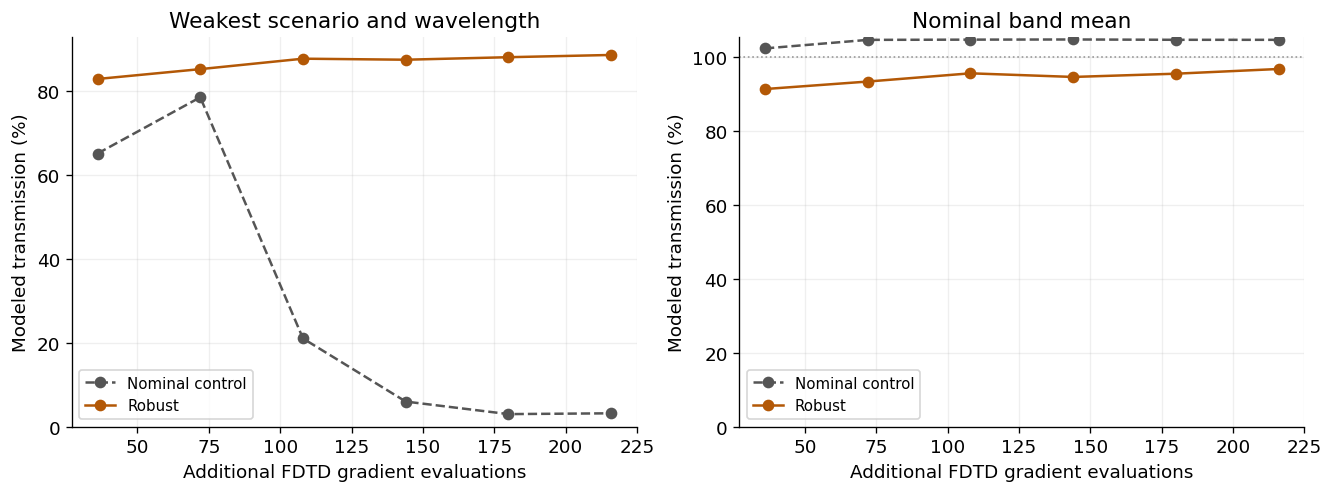

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
gradient_budget = np.arange(1, 7) * 36
for label, result, color, style in [("Nominal control", nominal_control, gray, "--"),
                                    ("Robust", robust_refinement, orange, "-")]:
    spectra = result["stage_spectra"]
    axes[0].plot(gradient_budget, 100 * spectra.min(axis=(1, 2)), color=color, linestyle=style, marker="o", label=label)
    axes[1].plot(gradient_budget, 100 * spectra[:, 1].mean(axis=1), color=color, linestyle=style, marker="o", label=label)
for ax in axes:
    ax.set(xlabel="Additional FDTD gradient evaluations", ylabel="Modeled transmission (%)", ylim=(0, None))
    ax.axhline(100, color="#999999", linestyle=":", linewidth=1)
    ax.grid(alpha=0.2); ax.legend(fontsize=9)
axes[0].set_title("Weakest scenario and wavelength")
axes[1].set_title("Nominal band mean")
plt.show()


### 12. Export and compare all three devices

These are independent binary contour exports at **β = 128, density level = 0.5**, using the same export procedure as Part I. The geometry comparison uses η = 0.50. The verification below also exports each perturbed threshold separately; it does not assess only the continuous training material.


**Reading the comparisons:** all three designs are optimized and simulated in BeamZ. “Meep baseline” labels the recreation of the reference problem, not results from a Meep solver run. The preceding continuous training curves include values above 100%; these are finite-grid/modal-measurement errors. Use the independently re-rasterized binary results below to assess device performance.

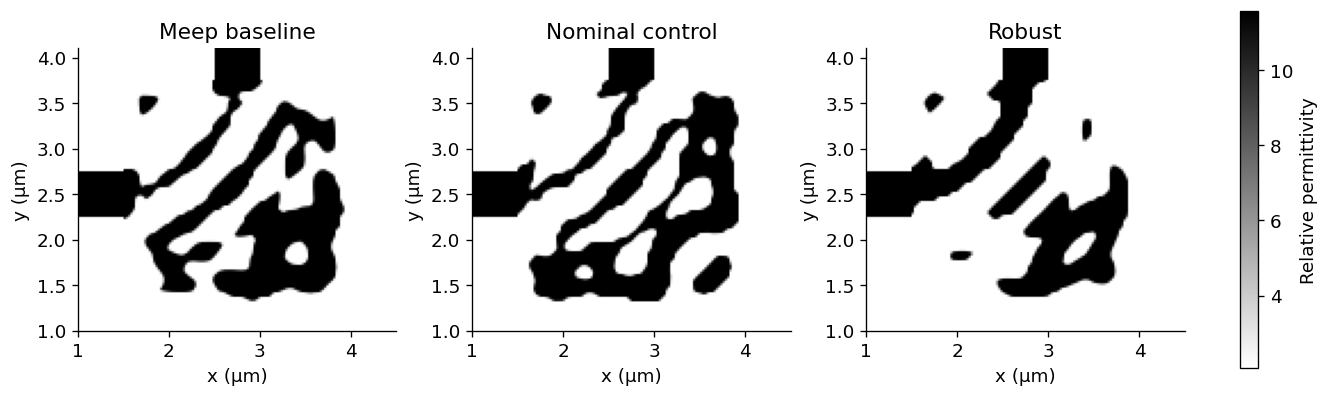

In [16]:
design_parameters = {"Meep baseline": baseline_parameters,
                     "Nominal control": control_parameters,
                     "Robust": robust_parameters}
design_colors = {"Meep baseline": blue, "Nominal control": gray, "Robust": orange}
design_styles = {"Meep baseline": ":", "Nominal control": "--", "Robust": "-"}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), layout="constrained")
for ax, (label, values) in zip(axes, design_parameters.items()):
    eps = exported_geometry(values).rasterize(25e-9).permittivity
    image = ax.imshow(eps, origin="lower", extent=(0, 5.5, 0, 5), cmap="gray_r",
                       vmin=1.44**2, vmax=3.4**2)
    ax.set(xlabel="x (µm)", ylabel="y (µm)", title=label, xlim=(1, 4.5), ylim=(1, 4.1))
fig.colorbar(image, ax=axes, label="Relative permittivity", shrink=0.8)
plt.show()


### 13. Verify binary robustness at intermediate thresholds and wavelengths

At **25 nm / 900 fs**, test η = **0.45, 0.475, 0.50, 0.525, 0.55**. The two intermediate thresholds were not optimized. The wavelength set is the union of the ten training wavelengths and a 21-point sweep, so all training points and additional wavelengths are present.

Every design is evaluated with the same source, monitors, mesh, duration, threshold set, and export rule. These deterministic threshold scenarios are fabrication proxies, not calibrated nanometre etch errors or a manufacturing-yield distribution. Only the design region varies; fixed leads remain unchanged.


Verified Meep baseline: worst of 145 pairs = 13.44%


Verified Nominal control: worst of 145 pairs = 0.29%


Verified Robust: worst of 145 pairs = 89.33%


Design | Nominal mean T (%) | Worst T across η and wavelength (%) | Maximum R (%)
--- | --- | --- | ---
Meep baseline | 89.54 | 13.44 | 66.88
Nominal control | 95.44 | 0.29 | 51.50
Robust | 93.27 | 89.33 | 1.35

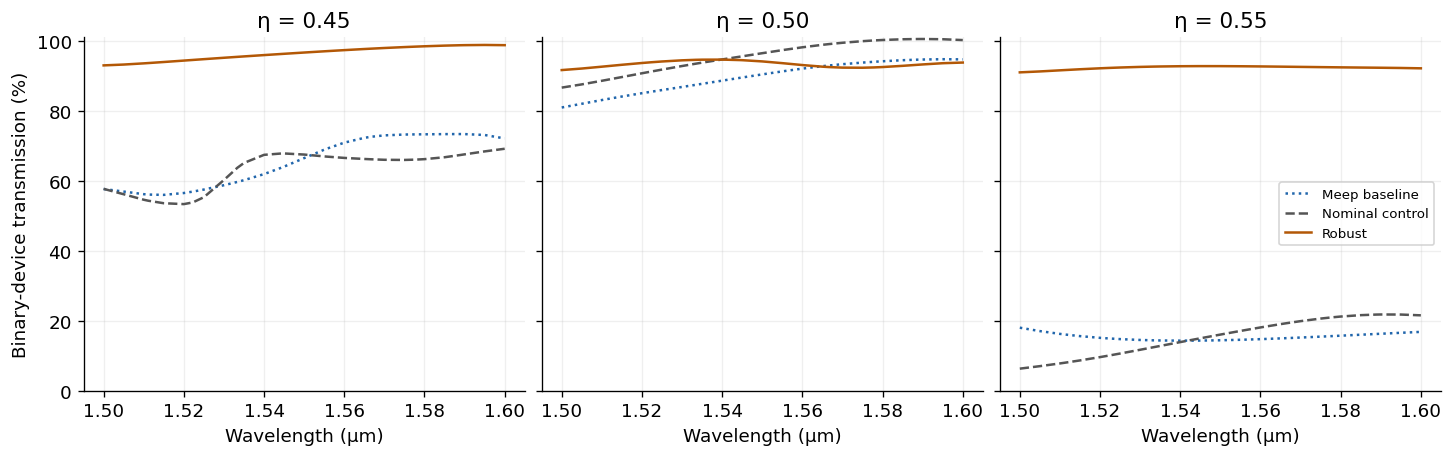

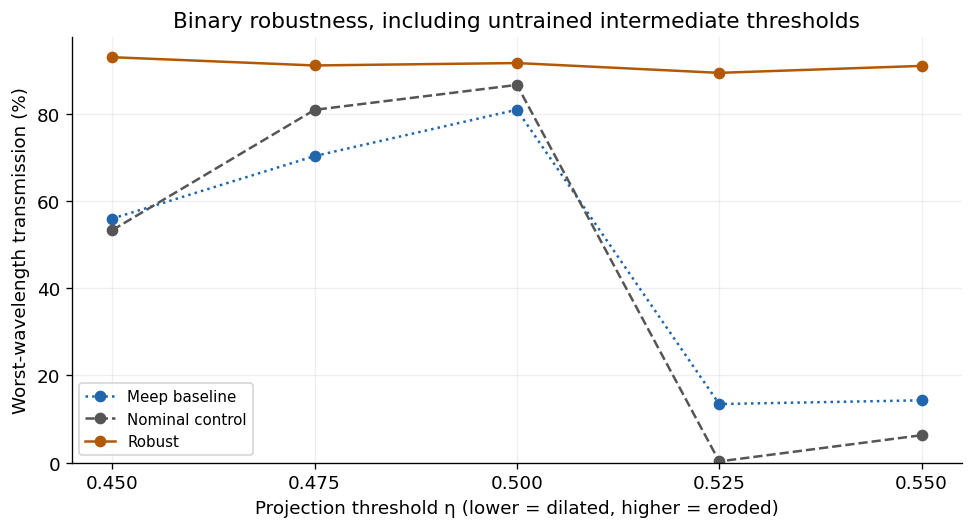

In [17]:
verification_etas = np.array([0.45, 0.475, 0.50, 0.525, 0.55])
robust_sweep_wavelengths = np.unique(np.r_[wavelengths, np.linspace(1.5, 1.6, 21) * um])
robust_sweep_monitors = [m.updated_copy(freqs=LIGHT_SPEED / robust_sweep_wavelengths)
                       for m in simulation.monitors]
binary_transmission = np.empty((3, len(verification_etas), len(robust_sweep_wavelengths)))
binary_reflection = np.empty_like(binary_transmission)
for design_index, (label, values) in enumerate(design_parameters.items()):
    for eta_index, eta in enumerate(verification_etas):
        data = simulation.updated_copy(design=exported_geometry(values, eta=eta),
            resolution=25e-9, run_time=900e-15, monitors=robust_sweep_monitors).run(
                backend="jax", performance=False)
        binary_transmission[design_index, eta_index], binary_reflection[design_index, eta_index] = measured_powers(data)
    print(f"Verified {label}: worst of {binary_transmission.shape[1] * binary_transmission.shape[2]} pairs = "
          f"{100 * binary_transmission[design_index].min():.2f}%")
assert np.isfinite(binary_transmission).all() and np.isfinite(binary_reflection).all()
show_table(["Design", "Nominal mean T (%)", "Worst T across η and wavelength (%)", "Maximum R (%)"],
           [[label, f"{100 * binary_transmission[i, 2].mean():.2f}",
             f"{100 * binary_transmission[i].min():.2f}", f"{100 * binary_reflection[i].max():.2f}"]
            for i, label in enumerate(design_parameters)])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), layout="constrained", sharey=True)
for ax, eta_index in zip(axes, [0, 2, 4]):
    for design_index, label in enumerate(design_parameters):
        ax.plot(robust_sweep_wavelengths / um, 100 * binary_transmission[design_index, eta_index],
                color=design_colors[label], linestyle=design_styles[label], label=label)
    ax.set(xlabel="Wavelength (µm)", title=f"η = {verification_etas[eta_index]:.2f}", ylim=(0, None))
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Binary-device transmission (%)")
axes[-1].legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.3), layout="constrained")
for i, label in enumerate(design_parameters):
    ax.plot(verification_etas, 100 * binary_transmission[i].min(axis=1), color=design_colors[label],
            linestyle=design_styles[label], marker="o", label=label)
ax.set(xlabel="Projection threshold η (lower = dilated, higher = eroded)",
       ylabel="Worst-wavelength transmission (%)",
       title="Binary robustness, including untrained intermediate thresholds", ylim=(0, None))
ax.set_xticks(verification_etas)
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.show()


### 14. Check finer meshes and a longer run

Re-solve the original baseline and robust binary devices at **12.5 nm / 900 fs**, at the three optimized thresholds and ten training wavelengths. Compare with the matching 25 nm samples. The nominal-control comparison above remains a 25 nm comparison; this finer check focuses on baseline versus robust.

Also shorten the 25 nm run to 700 fs at the robust design's weakest sampled threshold to measure residual time-window sensitivity. Finite checks and the improvement assertion below are executable checks, not assumptions used to construct the plots.


In [18]:
training_indices = [int(np.argmin(abs(robust_sweep_wavelengths - w))) for w in wavelengths]
scenario_indices = [0, 2, 4]
fine_transmission = np.empty((2, 3, len(wavelengths)))
fine_reflection = np.empty_like(fine_transmission)
fine_rows = []
for i, (label, values, coarse_index) in enumerate([
        ("Meep baseline", baseline_parameters, 0), ("Robust", robust_parameters, 2)]):
    for j, eta in enumerate(scenario_etas):
        if label == "Meep baseline" and eta == 0.50:
            transmission, reflection = verification[-1][2:]
        else:
            data = simulation.updated_copy(design=exported_geometry(values, eta=eta),
                resolution=12.5e-9, run_time=900e-15).run(backend="jax", performance=False)
            transmission, reflection = measured_powers(data)
        fine_transmission[i, j], fine_reflection[i, j] = transmission, reflection
        coarse = binary_transmission[coarse_index, scenario_indices[j], training_indices]
        fine_rows.append([label, f"{eta:.2f}", f"{100 * transmission.min():.2f}",
                          f"{100 * transmission.mean():.2f}",
                          f"{100 * np.max(abs(transmission - coarse)):.2f}"])
    print(f"Fine-grid {label}: minimum over three scenarios = {100 * fine_transmission[i].min():.2f}%")
show_table(["Design", "η", "Minimum T (%)", "Mean T (%)", "Max 25 → 12.5 nm change (pp)"], fine_rows)

weakest_eta_index = int(np.argmin(binary_transmission[2].min(axis=1)))
weakest_eta = verification_etas[weakest_eta_index]
short_run = simulation.updated_copy(design=exported_geometry(robust_parameters, eta=weakest_eta),
    resolution=25e-9, run_time=700e-15, monitors=robust_sweep_monitors).run(backend="jax", performance=False)
short_transmission, _ = measured_powers(short_run)
robust_runtime_change = np.max(abs(short_transmission - binary_transmission[2, weakest_eta_index]))
print(f"Robust worst-threshold 700 → 900 fs change: {100 * robust_runtime_change:.4f} percentage points")
assert np.isfinite(fine_transmission).all() and np.isfinite(fine_reflection).all()
assert binary_transmission[2].min() > binary_transmission[0].min() + 0.05
assert fine_transmission[1].min() > fine_transmission[0].min() + 0.05

np.savez_compressed(artifact_dir / "meep_filtered_bend_robust_comparison.npz",
    baseline_parameters=baseline_parameters, control_parameters=control_parameters, robust_parameters=robust_parameters,
    design_labels=np.array(list(design_parameters)), scenario_etas=scenario_etas, verification_etas=verification_etas,
    temperature=robust_temperature, wavelengths=robust_sweep_wavelengths,
    binary_transmission=binary_transmission, binary_reflection=binary_reflection,
    fine_wavelengths=wavelengths, fine_design_labels=np.array(["Meep baseline", "Robust"]),
    fine_transmission=fine_transmission, fine_reflection=fine_reflection,
    robust_history=robust_refinement["trial_history"], control_history=nominal_control["trial_history"],
    robust_stage_spectra=robust_refinement["stage_spectra"], control_stage_spectra=nominal_control["stage_spectra"],
    gradient_evaluations_each=216, run_time=900e-15, coarse_resolution=25e-9, fine_resolution=12.5e-9,
    runtime_change=robust_runtime_change)


Fine-grid Meep baseline: minimum over three scenarios = 13.23%


Fine-grid Robust: minimum over three scenarios = 92.01%


Design | η | Minimum T (%) | Mean T (%) | Max 25 → 12.5 nm change (pp)
--- | --- | --- | --- | ---
Meep baseline | 0.45 | 56.97 | 65.86 | 1.42
Meep baseline | 0.50 | 84.23 | 89.77 | 3.35
Meep baseline | 0.55 | 13.23 | 14.51 | 1.95
Robust | 0.45 | 95.19 | 96.87 | 2.28
Robust | 0.50 | 92.09 | 93.60 | 2.00
Robust | 0.55 | 92.01 | 92.40 | 1.17

Robust worst-threshold 700 → 900 fs change: 0.0000 percentage points


## Next Steps

The robust refinement and comparison now live in this notebook. The remaining fabrication work is to calibrate the scenario model to a physical process and add explicit minimum-width/minimum-gap constraints. Robustness to these sampled thresholds does not establish foundry manufacturability, a yield percentage, or robustness outside the sampled range.


In [19]:
display(Markdown(
    f"**Robustness result:** on the common 25 nm verification grid, worst sampled transmission improves "
    f"from **{100 * binary_transmission[0].min():.2f}%** (Meep baseline) to "
    f"**{100 * binary_transmission[2].min():.2f}%** (robust refinement). "
    f"The equal-gradient-budget nominal control reaches **{100 * binary_transmission[1].min():.2f}%**. "
    f"Nominal band means are **{100 * binary_transmission[0, 2].mean():.2f}% / "
    f"{100 * binary_transmission[1, 2].mean():.2f}% / {100 * binary_transmission[2, 2].mean():.2f}%**, "
    "respectively. "
    f"At 12.5 nm, the baseline/robust worst transmissions across the three optimized thresholds "
    f"and ten training wavelengths are **{100 * fine_transmission[0].min():.2f}% / "
    f"{100 * fine_transmission[1].min():.2f}%**. "
    "These results apply to the modeled density-threshold scenarios in this 2D example."
))
print("Comparison artifact:", artifact_dir / "meep_filtered_bend_robust_comparison.npz")


**Robustness result:** on the common 25 nm verification grid, worst sampled transmission improves from **13.44%** (Meep baseline) to **89.33%** (robust refinement). The equal-gradient-budget nominal control reaches **0.29%**. Nominal band means are **89.54% / 95.44% / 93.27%**, respectively. At 12.5 nm, the baseline/robust worst transmissions across the three optimized thresholds and ten training wavelengths are **13.23% / 92.01%**. These results apply to the modeled density-threshold scenarios in this 2D example.

Comparison artifact: /Users/quentinwach/.t3/worktrees/beamz-1/t3code-171ec700/results/topology_examples/meep_filtered_bend_robust_comparison.npz
